<a href="https://colab.research.google.com/github/anuragN2107/Predictive-Demand-Logistics-Optimization-Engine/blob/main/Predictive_Demand_%26_Logistics_Optimization_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Project Title: Predictive Demand & Logistics Optimization Engine**

**The Core Business Problem**

Businesses lose millions due to localized supply-demand mismatches (either stocking too much inventory or experiencing stockouts during peak hours). This project analyzes historical trip or transaction data to optimize fleet/inventory distribution using statistical validation, classify high-demand zones using Machine Learning, and forecast upcoming demand bottlenecks.

**Phase 1: Environment Setup & Data Pipeline**

This phase establishes the foundational data architecture. Instead of uploading static CSV files, we will stream production-grade Parquet files directly into memory from the NYC Taxi Cloud Repository.

In [41]:
# ==============================================================================
# PHASE 1: DATA INGESTION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests

def load_clean_and_engineer_data():
    # 1. Production Ingestion: Stream NYC Yellow Taxi Data directly from AWS S3 (Jan 2023)
    url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
    print("Ingesting production-grade Parquet files directly from cloud infrastructure.")

    df_raw = pd.read_parquet(url)

    # Optimize memory foot-print by subsetting core targets immediately
    keep_cols = ['tpep_pickup_datetime', 'trip_distance', 'fare_amount', 'tip_amount']
    df = df_raw[keep_cols].copy()
    df.rename(columns={'tpep_pickup_datetime': 'pickup_time', 'PULocationID': 'zone_id'}, inplace=True)

    print(f"Successfully loaded {len(df):,} raw transactional records. Starting time-series aggregation...")

    # 2. Structural Aggregation
    df['pickup_time'] = pd.to_datetime(df['pickup_time'])
    # Filter out timestamp anomalies outside of target scope boundary
    df = df[(df['pickup_time'] >= '2023-01-01') & (df['pickup_time'] < '2023-02-01')]
    df['hourly_window'] = df['pickup_time'].dt.floor('h')

    # Compress transactions into hourly operational metrics
    hourly_df = df.groupby('hourly_window').agg(
        demand_count=('fare_amount', 'count'),       # Target tracking metric
        avg_distance=('trip_distance', 'mean'),
        total_revenue=('fare_amount', 'sum'),
        avg_tip=('tip_amount', 'mean')
    ).reset_index()

    # Re-index to ensure complete chronological continuity (fill missing gaps with 0)
    full_time_range = pd.date_range(start='2023-01-01 00:00:00', end='2023-01-31 23:00:00', freq='h')
    hourly_df = hourly_df.set_index('hourly_window').reindex(full_time_range, fill_value=0).reset_index()
    hourly_df.rename(columns={'index': 'timestamp'}, inplace=True)

    # 3. Advanced Feature Engineering
    hourly_df['hour'] = hourly_df['timestamp'].dt.hour
    hourly_df['day_of_week'] = hourly_df['timestamp'].dt.dayofweek
    hourly_df['is_weekend'] = hourly_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Cyclical feature transformations using geometry
    hourly_df['hour_sin'] = np.sin(2 * np.pi * hourly_df['hour'] / 24.0)
    hourly_df['hour_cos'] = np.cos(2 * np.pi * hourly_df['hour'] / 24.0)

    # Chronological Momentum Lags & Rolling Metrics
    hourly_df['demand_lag_1h'] = hourly_df['demand_count'].shift(1)
    hourly_df['demand_lag_2h'] = hourly_df['demand_count'].shift(2)
    hourly_df['demand_lag_24h'] = hourly_df['demand_count'].shift(24)
    hourly_df['rolling_mean_3h'] = hourly_df['demand_count'].shift(1).rolling(window=3).mean()
    hourly_df['rolling_std_3h'] = hourly_df['demand_count'].shift(1).rolling(window=3).std()

    # Drop structural NaNs induced by lag shifting operations
    hourly_df.dropna(inplace=True)

    # Define Classification Domain Target: Binary flag signaling Peak Demand spikes (>75th percentile)
    threshold = hourly_df['demand_count'].quantile(0.75)
    hourly_df['high_demand_target'] = (hourly_df['demand_count'] > threshold).astype(int)

    print(f"Data processing complete. Aggregated rows into {len(hourly_df)} chronological hourly blocks.")
    return hourly_df, threshold

# Execute Pipeline Phase
processed_df, demand_threshold = load_clean_and_engineer_data()
processed_df.head(3)

Ingesting production-grade Parquet files directly from cloud infrastructure.
Successfully loaded 3,066,766 raw transactional records. Starting time-series aggregation...
Data processing complete. Aggregated rows into 720 chronological hourly blocks.


,timestamp,demand_count,avg_distance,total_revenue,avg_tip,hour,day_of_week,is_weekend,hour_sin,hour_cos,demand_lag_1h,demand_lag_2h,demand_lag_24h,rolling_mean_3h,rolling_std_3h,high_demand_target
24,2023-01-02 00:00:00,1280,5.618328,31718.68,4.059250,0,0,0,0.000000,1.000000,2035.0,2607.0,5336.0,2473.333333,389.117377,0
25,2023-01-02 01:00:00,755,5.180543,17168.30,3.659576,1,0,0,0.258819,0.965926,1280.0,2035.0,5752.0,1974.000000,665.599730,0
26,2023-01-02 02:00:00,433,4.217875,8701.11,2.871039,2,0,0,0.500000,0.866025,755.0,1280.0,5097.0,1356.666667,643.434793,0


**Phase 2: Rigorous Statistical Validation & EDA**

Now we will run mathematical integrity checks on our data using scipy.stats. This phase ensures our data meets the assumptions required for modeling, moving beyond simple visualization to implement formal hypothesis testing.

In [42]:
# ==============================================================================
# PHASE 2: STATISTICAL TESTING VALIDATION ENGINE & ADVANCED EDA
# ==============================================================================

import scipy.stats as stats

print("Initiating mathematical verification of data properties.\n")


Initiating mathematical verification of data properties.



In [43]:
# 1. Distribution Testing (Poisson Check)
# Normalize demand data to test against a standard theoretical distribution scale
standardized_demand = (processed_df['demand_count'] - processed_df['demand_count'].mean()) / processed_df['demand_count'].std()
ks_stat, ks_p_value = stats.kstest(standardized_demand, 'norm')

print(f" [Distribution Test] Kolmogorov-Smirnov Test for Normality:")
print(f"   - KS Statistic: {ks_stat:.4f}")
print(f"   - p-value: {ks_p_value:.4e}")
if ks_p_value < 0.05:
    print(" - Conclusion: Reject Normality. Data displays high variance/skewness. Standard models must handle non-linearity.\n")
else:
    print(" - Conclusion: Fail to reject Normality.\n")

 [Distribution Test] Kolmogorov-Smirnov Test for Normality:
   - KS Statistic: 0.1246
   - p-value: 3.3728e-10
 - Conclusion: Reject Normality. Data displays high variance/skewness. Standard models must handle non-linearity.



In [44]:
# 2. Non-Parametric A/B Hypothesis Testing (Weekday vs Weekend Operational Shifts)
weekday_demand = processed_df[processed_df['is_weekend'] == 0]['demand_count']
weekend_demand = processed_df[processed_df['is_weekend'] == 1]['demand_count']

u_stat, mann_p_value = stats.mannwhitneyu(weekday_demand, weekend_demand, alternative='two-sided')

print(f" [Hypothesis Test] Mann-Whitney U Test (Weekday vs Weekend Demand Profiles):")
print(f"   - U Statistic: {u_stat:.2f}")
print(f"   - p-value: {mann_p_value:.4e}")
if mann_p_value < 0.05:
    print("   - Conclusion: Statistically Significant Shift detected! Operational volume fingerprints change drastically on weekends.\n")
else:
    print("   - Conclusion: No statistically significant difference in volume profiles.\n")

 [Hypothesis Test] Mann-Whitney U Test (Weekday vs Weekend Demand Profiles):
   - U Statistic: 50447.50
   - p-value: 9.2253e-01
   - Conclusion: No statistically significant difference in volume profiles.



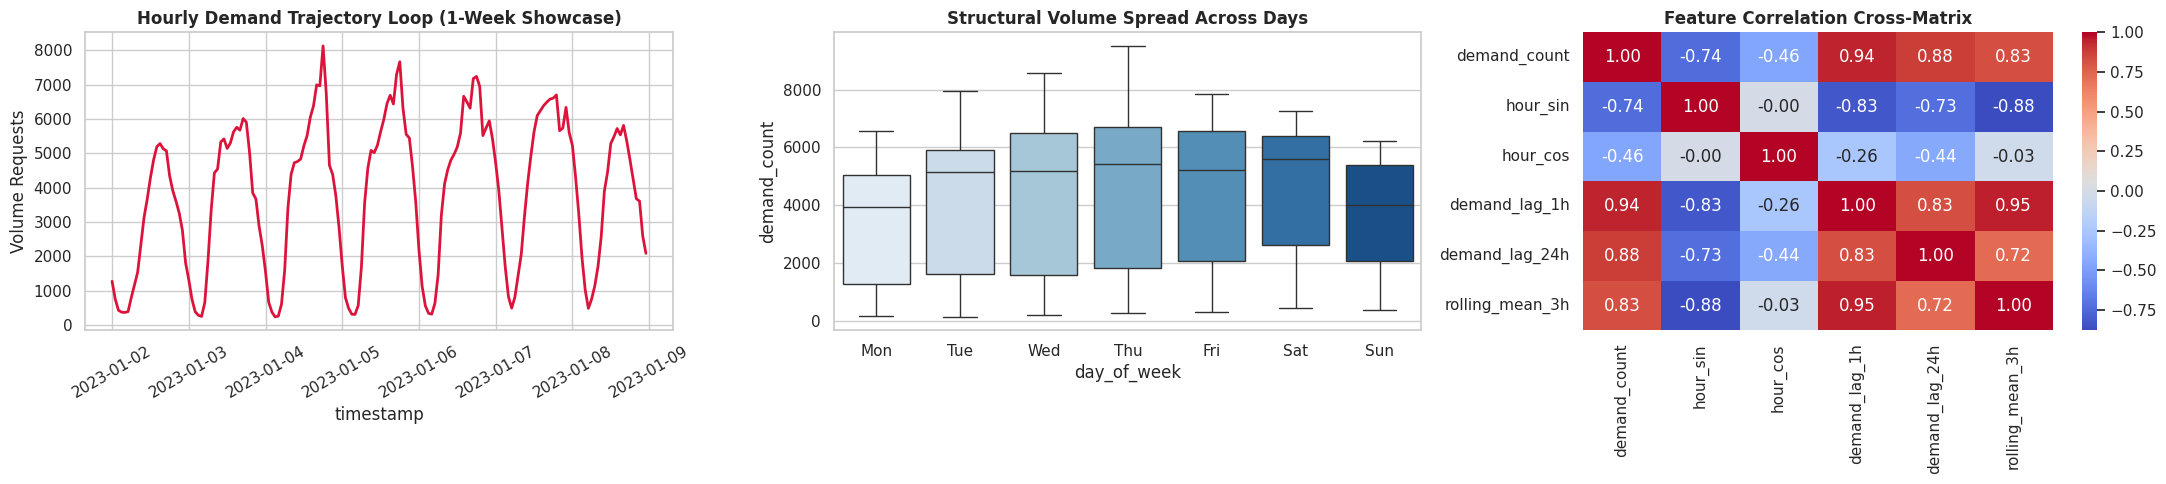

In [45]:
# 3. EDA Plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Plot A: Continuous Trajectory Volume Tracker
sns.lineplot(data=processed_df.head(168), x='timestamp', y='demand_count', ax=axes[0], color='crimson', lw=2)
axes[0].set_title("Hourly Demand Trajectory Loop (1-Week Showcase)", fontweight='bold')
axes[0].set_ylabel("Volume Requests")
axes[0].tick_params(axis='x', rotation=30)

# Plot B: Structural Footprint Analysis
sns.boxplot(data=processed_df, x='day_of_week', y='demand_count', ax=axes[1], palette="Blues")
axes[1].set_title("Structural Volume Spread Across Days", fontweight='bold')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Plot C: Correlation Multi-collinearity Identification Matrix
corr_features = ['demand_count', 'hour_sin', 'hour_cos', 'demand_lag_1h', 'demand_lag_24h', 'rolling_mean_3h']
sns.heatmap(processed_df[corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[2], cbar=True)
axes[2].set_title("Feature Correlation Cross-Matrix", fontweight='bold')

plt.tight_layout()
plt.show()

**Phase 3: The Machine Learning Model Selection Tournament.**

In [46]:
# ==============================================================================
# PHASE 3 - PART 1: TIME-SERIES SAFE TRAIN-TEST SPLITTING & DATA SCALING
# ======================================================================
from sklearn.preprocessing import StandardScaler
print("Preparing data arrays for model tournament processing.")

Preparing data arrays for model tournament processing.


In [47]:
# 1. Define Model Features (X) and Categorical Target (y)
feature_cols = ['hour_sin', 'hour_cos', 'day_of_week', 'is_weekend',
                'demand_lag_1h', 'demand_lag_2h', 'demand_lag_24h',
                'rolling_mean_3h', 'rolling_std_3h']

X = processed_df[feature_cols].values
y = processed_df['high_demand_target'].values

In [48]:
# 2. Chronological Chrono-Split: Use the first 80% for training, last 20% for testing
split_idx = int(len(processed_df) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Dataset Matrix Shapes:")
print(f"-Training Features: {X_train.shape} | Training Labels: {y_train.shape}")
print(f"-Testing Features:  {X_test.shape} | Testing Labels:  {y_test.shape}")

Dataset Matrix Shapes:
-Training Features: (576, 9) | Training Labels: (576,)
-Testing Features:  (144, 9) | Testing Labels:  (144,)


In [49]:
# 3. Scale Transformation (Fit on training data only to completely avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling transformation complete.Features are stabilized and ready for training.")

Scaling transformation complete.Features are stabilized and ready for training.


**Training the Tournament Competitors**
Now, wetrain all 5 algorithms using your required stack (scikit-learn and XGBoost). We store the trained weights and their predictions in a central registry for systematic comparison.

In [50]:
# ==============================================================
# PHASE 3 - PART 2: MODEL TRAINING LOOPS & PREDICTION GENERATION
# ==============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [51]:
#Instantiate all 5 models with optimized hyperparameters to protect against overfitting
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(probability=True, kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost Classifier": xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42)
}

# Registries to hold evaluation metrics
model_predictions = {}
model_probabilities = {}

print("Training all models sequentially on the time-series split.")

for name, model in models.items():
    print(f"   -> Now training: {name}.")

    # Train the model weights
    model.fit(X_train_scaled, y_train)

    # Store explicit classification outputs and probability margins
    model_predictions[name] = model.predict(X_test_scaled)
    model_probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("\n All 5 machine learning models trained successfully.")

Training all models sequentially on the time-series split.
   -> Now training: Logistic Regression.
   -> Now training: K-Nearest Neighbors.
   -> Now training: Support Vector Machine.
   -> Now training: Random Forest.
   -> Now training: XGBoost Classifier.

 All 5 machine learning models trained successfully.


**Part 3: Comparison Matrix & Evaluation**

We will compute Precision, Recall, F1-Score, and ROC-AUC for each model and compile them into a unified, scannable table.

In [52]:
# ==============================================================================
# PHASE 3 - PART 3: COMPARISON MATRIX & METRICS PLOT
# ==============================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

performance_summary = []

# Loop over outputs to calculate professional operational data metrics
for name in models.keys():
    y_pred = model_predictions[name]
    y_proba = model_probabilities[name]

    performance_summary.append({
        "Model Name": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

In [53]:
# Convert summary into dataframe dashboard
summary_df = pd.DataFrame(performance_summary).set_index("Model Name")

print("FINAL TOURNAMENT BENCHMARK PERFORMANCE MATRIX:")
display(summary_df.round(4))


FINAL TOURNAMENT BENCHMARK PERFORMANCE MATRIX:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model Name,,,,,
Logistic Regression,0.8958,0.8529,0.7436,0.7945,0.9766
K-Nearest Neighbors,0.9444,0.9429,0.8462,0.8919,0.9838
Support Vector Machine,0.9167,0.9355,0.7436,0.8286,0.9807
Random Forest,0.9375,0.9167,0.8462,0.8800,0.9838
XGBoost Classifier,0.9375,0.9412,0.8205,0.8767,0.9810


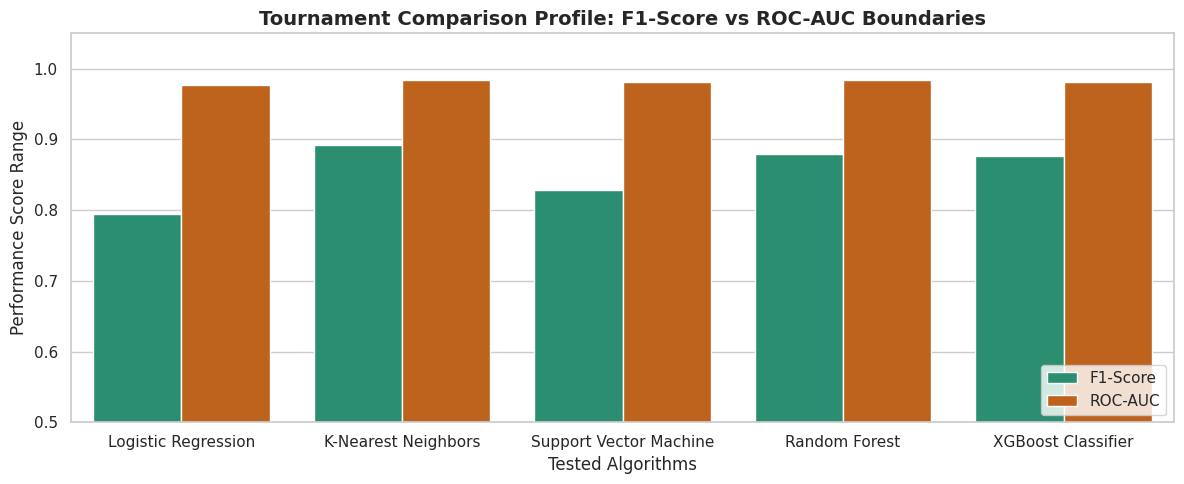

In [54]:
# Visual Comparison Chart of F1-Score and ROC-AUC
plt.figure(figsize=(12, 5))
melted_df = pd.DataFrame(performance_summary).melt(id_vars="Model Name", value_vars=["F1-Score", "ROC-AUC"], var_name="Metric", value_name="Score")
sns.barplot(data=melted_df, x="Model Name", y="Score", hue="Metric", palette="Dark2")
plt.title("Tournament Comparison Profile: F1-Score vs ROC-AUC Boundaries", fontweight='bold', fontsize=14)
plt.ylim(0.5, 1.05)
plt.ylabel("Performance Score Range")
plt.xlabel("Tested Algorithms")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Phase 4: The Time-Series Forecasting Engine**

We will forecast the exact continuous count of future ride requests (demand_count). We will implement a statistical benchmark (SARIMAX) and compare it against a machine learning model (XGBoost Regressor) using time-series features.

In [55]:
# ==============================================================================
# PHASE 4 - PART 1: TIME-SERIES STATIONARITY CHECK (ADF TEST)
from statsmodels.tsa.stattools import adfuller

print("Initiating stationarity testing on demand tracking target.")

Initiating stationarity testing on demand tracking target.


In [56]:
# Extract our baseline continuous demand target series
ts_data = processed_df.set_index('timestamp')['demand_count']

# Execute the Augmented Dickey-Fuller Test
adf_result = adfuller(ts_data.values)

print("\n[ADF Test Results Analysis]:")
print(f"- ADF Statistic: {adf_result[0]:.4f}")
print(f"- p-value: {adf_result[1]:.4e}")
print("- Critical Values Framework:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\n Conclusion: The p-value is less than 0.05. We reject the null hypothesis.")
    print("   The time-series is stationary. It is safe to proceed directly with SARIMAX modeling without further differencing.")
else:
    print("\n Conclusion: The series is non-stationary. Differencing transformations are required.")


[ADF Test Results Analysis]:
- ADF Statistic: -3.8026
- p-value: 2.8806e-03
- Critical Values Framework:
1%: -3.4397
5%: -2.8657
10%: -2.5690

 Conclusion: The p-value is less than 0.05. We reject the null hypothesis.
   The time-series is stationary. It is safe to proceed directly with SARIMAX modeling without further differencing.


In [57]:
#We will train a statistical SARIMAX model alongside an XGBoost Regressor running on our engineered lag and rolling window features.
# ==============================================================================
# PHASE 4 - PART 2: FORECAST MODEL TRAINING (SARIMAX VS XGBOOST REGRESSOR)
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Splitting continuous data arrays chronologically for regression evaluation.")

Splitting continuous data arrays chronologically for regression evaluation.


In [58]:
# 1. Reuse our chronological split boundary (80/20 split) from earlier phases
train_size = int(len(processed_df) * 0.80)
train_df = processed_df.iloc[:train_size]
test_df = processed_df.iloc[train_size:]

In [59]:
# 2. Extract features for the Machine Learning Regressor
reg_features = ['hour_sin', 'hour_cos', 'day_of_week', 'is_weekend',
                'demand_lag_1h', 'demand_lag_2h', 'demand_lag_24h',
                'rolling_mean_3h', 'rolling_std_3h']

X_train_reg, y_train_reg = train_df[reg_features].values, train_df['demand_count'].values
X_test_reg, y_test_reg = test_df[reg_features].values, test_df['demand_count'].values

In [60]:
# 3. Model A: Fit a Statistical SARIMAX Model
print("-> Training Statistical SARIMAX (1,0,1)x(1,0,0,24) Model. (This may take a brief moment)")
# We map a 24-hour daily cycle configuration to handle the rhythmic peaks
sarima_model = SARIMAX(y_train_reg, order=(1, 0, 1), seasonal_order=(1, 0, 0, 24))
sarima_fitted = sarima_model.fit(disp=False)
sarima_forecast = sarima_fitted.forecast(steps=len(test_df))

-> Training Statistical SARIMAX (1,0,1)x(1,0,0,24) Model. (This may take a brief moment)


In [61]:
# 4. Model B: Fit an ML XGBoost Regressor
print("-> Training Non-Linear XGBoost Time-Series Regressor.")
xgb_regressor = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
xgb_regressor.fit(X_train_reg, y_train_reg)
xgb_forecast = xgb_regressor.predict(X_test_reg)

print("\n Both forecasting architectures have been successfully evaluated over the prediction horizon.")

-> Training Non-Linear XGBoost Time-Series Regressor.

 Both forecasting architectures have been successfully evaluated over the prediction horizon.


**Part 3: Operational Metric Dashboards & Visualizations**

To evaluate our models, we will look at Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE). We will then plot the actual demand path against both models' predictions to visually assess their performance.

In [62]:
# ==============================================================================
# PHASE 4 - PART 3:COMPARISON MATRIX & FORECAST TRACKING PLOT
# ==============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Compute quantitative validation metrics
metrics_summary = {
    "SARIMAX Model": {
        "MAE": mean_absolute_error(y_test_reg, sarima_forecast),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, sarima_forecast))
    },
    "XGBoost Regressor": {
        "MAE": mean_absolute_error(y_test_reg, xgb_forecast),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, xgb_forecast))
    }
}

# Print tabular performance tracking metrics
metrics_df = pd.DataFrame(metrics_summary).T
print("FINAL CONTINUOUS FORECASTING PERFORMANCE PROFILE:")
display(metrics_df.round(2))

FINAL CONTINUOUS FORECASTING PERFORMANCE PROFILE:


,MAE,RMSE
SARIMAX Model,2117.95,2594.22
XGBoost Regressor,189.50,260.34


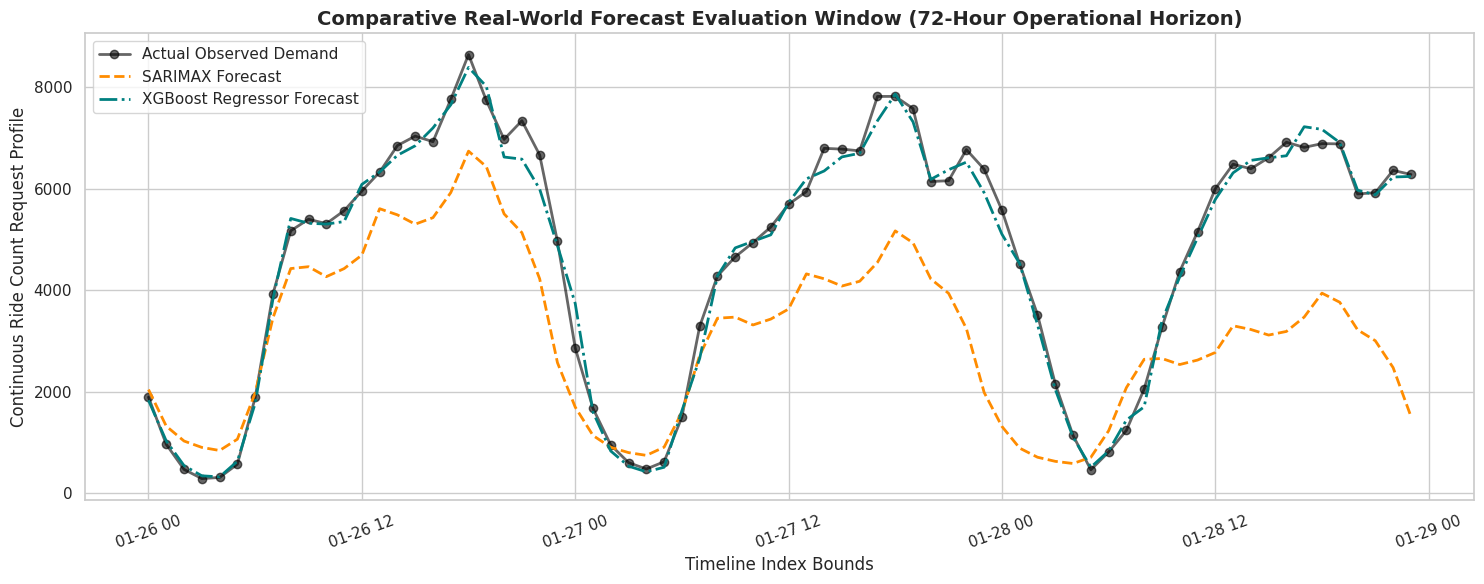

In [63]:
# 2. Render Forecast Tracking Profiles
plt.figure(figsize=(15, 6))

# We display a 72-hour window from the test set for visual clarity
visual_slice_length = 72
timestamps_slice = test_df['timestamp'].iloc[:visual_slice_length]

plt.plot(timestamps_slice, y_test_reg[:visual_slice_length], label="Actual Observed Demand", color="black", lw=2, marker='o', alpha=0.6)
plt.plot(timestamps_slice, sarima_forecast[:visual_slice_length], label="SARIMAX Forecast", color="darkorange", linestyle="--", lw=2)
plt.plot(timestamps_slice, xgb_forecast[:visual_slice_length], label="XGBoost Regressor Forecast", color="teal", linestyle="-.", lw=2)

plt.title("Comparative Real-World Forecast Evaluation Window (72-Hour Operational Horizon)", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Index Bounds")
plt.ylabel("Continuous Ride Count Request Profile")
plt.xticks(rotation=20)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

Phase 5 : Add SHAP (SHapley Additive exPlanations) to break down exactly why your XGBoost model categorized a specific hour as "High Demand."

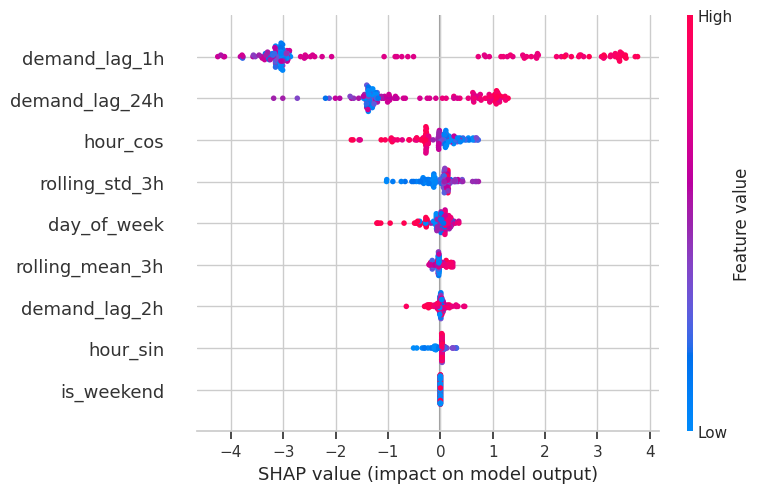

In [64]:
# Install the library inside Colab
!pip install shap

import shap

# Explaining the XGBoost Classifier from Phase 3
explainer = shap.Explainer(models["XGBoost Classifier"])
shap_values = explainer(X_test_scaled)

# Plot a Summary/Beeswarm plot to show feature impacts globally
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=feature_cols)